# Notebook 03 — Exploratory Data Analysis (EDA)

**Project:** Why Startups Fail — VC Investment Pattern Analysis  
**Team:** Section C, Group 17  

---
**Objective:** Uncover distributions, trends, and anomalies in the cleaned dataset. Each visualisation is accompanied by a written business insight.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

COLORS = {'closed': '#E74C3C', 'operating': '#2ECC71', 'acquired': '#3498DB', 'ipo': '#F39C12'}

df = pd.read_csv('/content/startups_cleaned.csv', low_memory=False)
print(f'Loaded cleaned data: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('Status distribution:')
print(df['status'].value_counts().to_string())

Loaded cleaned data: 7,803 rows x 47 columns
Status distribution:
status
operating    6785
acquired      651
closed        367


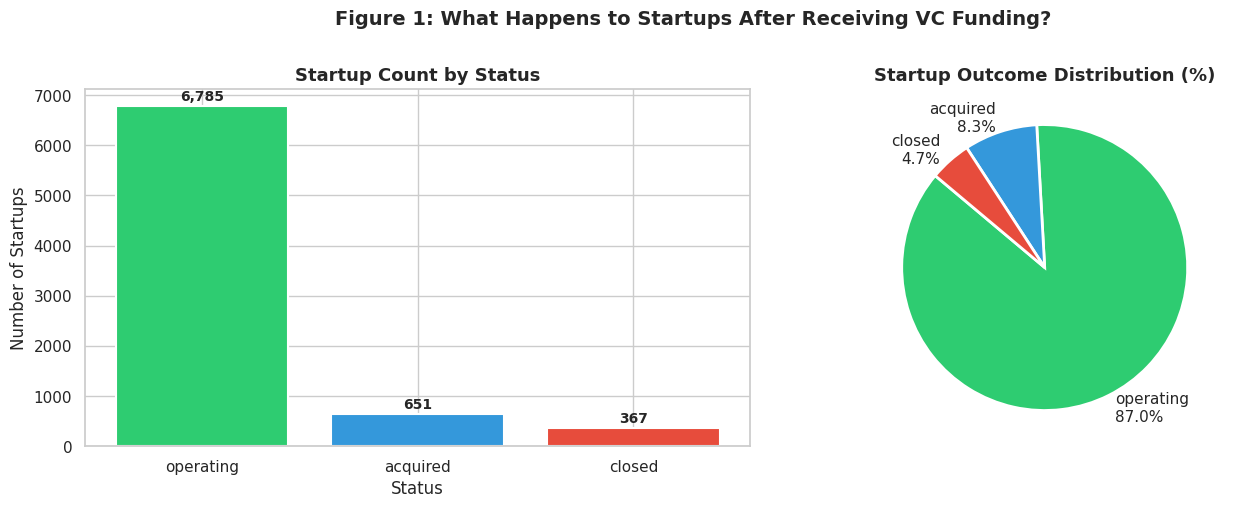

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
from google.colab import files

status_counts = df['status'].value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(
    status_counts.index,
    status_counts.values,
    color=[COLORS.get(s, '#95A5A6') for s in status_counts.index],
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, status_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{val:,}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[0].set_title('Startup Count by Status', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Startups')
axes[0].set_xlabel('Status')

# Pie chart
axes[1].pie(
    status_pct.values,
    labels=[f'{s}\n{p}%' for s, p in status_pct.items()],
    colors=[COLORS.get(s, '#95A5A6') for s in status_pct.index],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[1].set_title('Startup Outcome Distribution (%)', fontweight='bold', fontsize=13)

plt.suptitle(
    'Figure 1: What Happens to Startups After Receiving VC Funding?',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

# SHOW plot
plt.show()

# ---- DOWNLOAD PART ----
filename = "eda_01_status_distribution.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

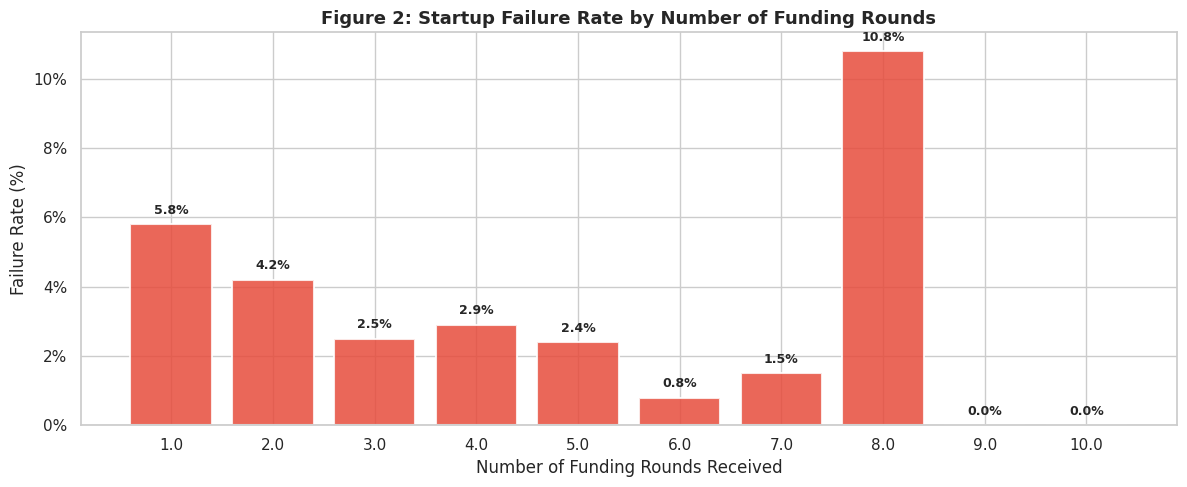

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import files

df_rounds = df[df['funding_rounds'] <= 10].copy()

closure_by_rounds = df_rounds.groupby('funding_rounds')['is_closed'].mean().reset_index()
closure_by_rounds.columns = ['funding_rounds', 'failure_rate']
closure_by_rounds['failure_rate_pct'] = (closure_by_rounds['failure_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    closure_by_rounds['funding_rounds'].astype(str),
    closure_by_rounds['failure_rate_pct'],
    color='#E74C3C',
    alpha=0.85,
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, closure_by_rounds['failure_rate_pct']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Figure 2: Startup Failure Rate by Number of Funding Rounds',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Number of Funding Rounds Received')
ax.set_ylabel('Failure Rate (%)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.tight_layout()

# SHOW plot
plt.show()

# ---- DOWNLOAD (NO FILESYSTEM) ----
filename = "eda_02_failure_by_rounds.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

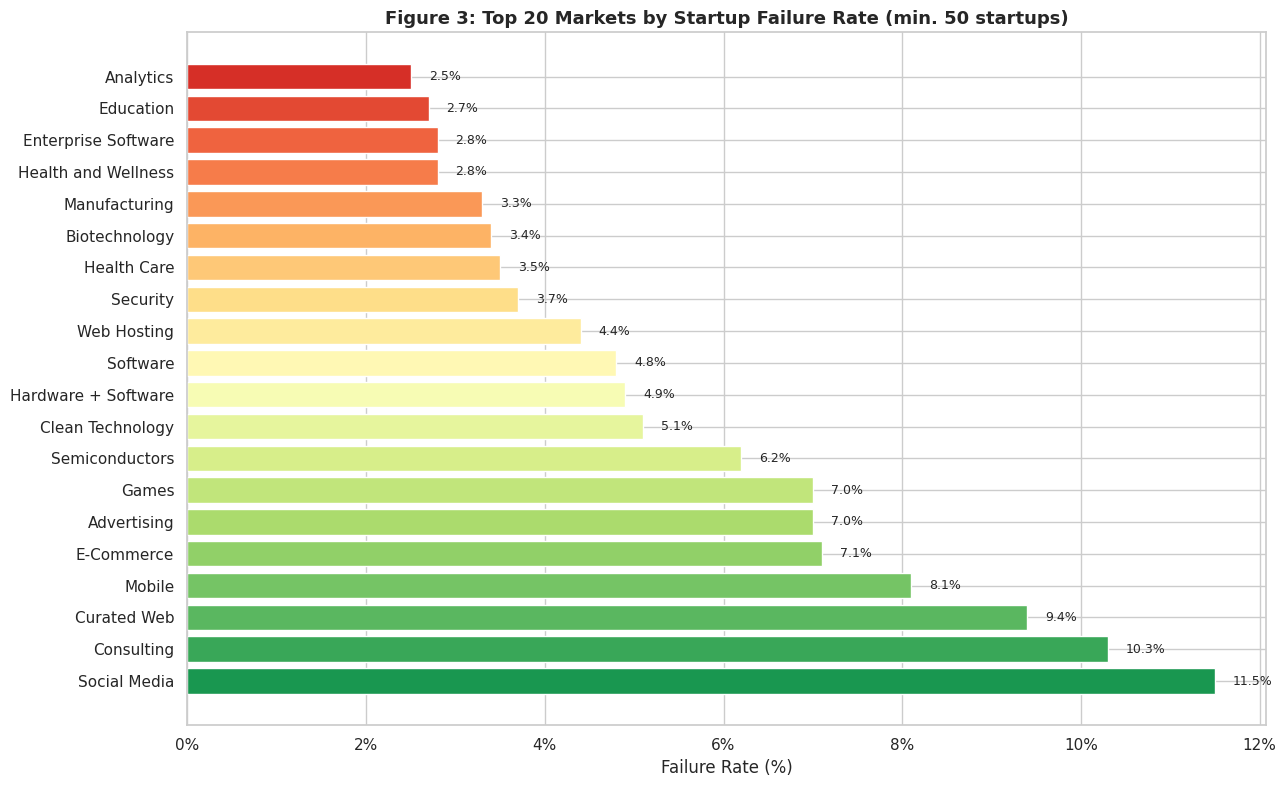

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import files

sector_stats = df.groupby('market').agg(
    total=('is_closed', 'count'),
    closed=('is_closed', 'sum')
).reset_index()

sector_stats = sector_stats[sector_stats['total'] >= 50]
sector_stats['failure_rate'] = (sector_stats['closed'] / sector_stats['total'] * 100).round(1)
sector_stats = sector_stats.sort_values('failure_rate', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(
    sector_stats['market'],
    sector_stats['failure_rate'],
    color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sector_stats))),
    edgecolor='white',
    linewidth=1
)

for bar, val in zip(bars, sector_stats['failure_rate']):
    ax.text(
        val + 0.2,
        bar.get_y() + bar.get_height()/2,
        f'{val}%',
        va='center',
        fontsize=9
    )

ax.set_title(
    'Figure 3: Top 20 Markets by Startup Failure Rate (min. 50 startups)',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Failure Rate (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.tight_layout()

# SHOW plot
plt.show()

# ---- DOWNLOAD ----
filename = "eda_03_failure_by_market.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

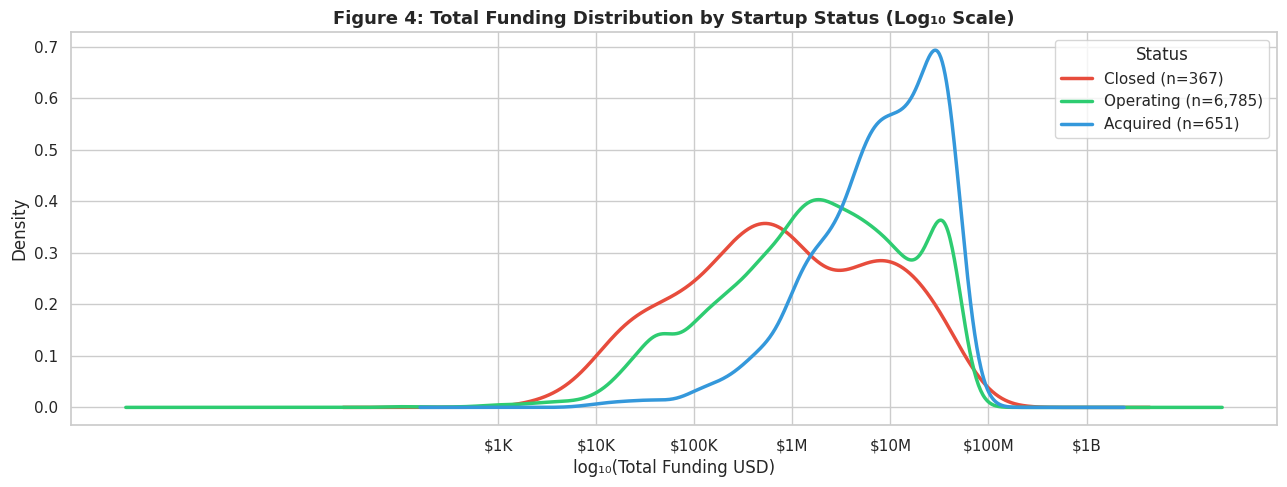

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

df_fund = df[df['funding_total_usd'] > 0].copy()
df_fund['log_funding'] = np.log10(df_fund['funding_total_usd'])

fig, ax = plt.subplots(figsize=(13, 5))

for status in ['closed', 'operating', 'acquired', 'ipo']:
    subset = df_fund[df_fund['status'] == status]['log_funding']

    if len(subset) > 0:
        subset.plot.kde(
            ax=ax,
            label=f'{status.title()} (n={len(subset):,})',
            color=COLORS.get(status),
            linewidth=2.5
        )

ax.set_title(
    'Figure 4: Total Funding Distribution by Startup Status (Log₁₀ Scale)',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('log₁₀(Total Funding USD)')
ax.set_ylabel('Density')

ax.legend(title='Status')

x_ticks = [3, 4, 5, 6, 7, 8, 9]
ax.set_xticks(x_ticks)
ax.set_xticklabels(['$1K', '$10K', '$100K', '$1M', '$10M', '$100M', '$1B'])

plt.tight_layout()

# SHOW plot
plt.show()

# ---- DOWNLOAD ----
filename = "eda_04_funding_distribution.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

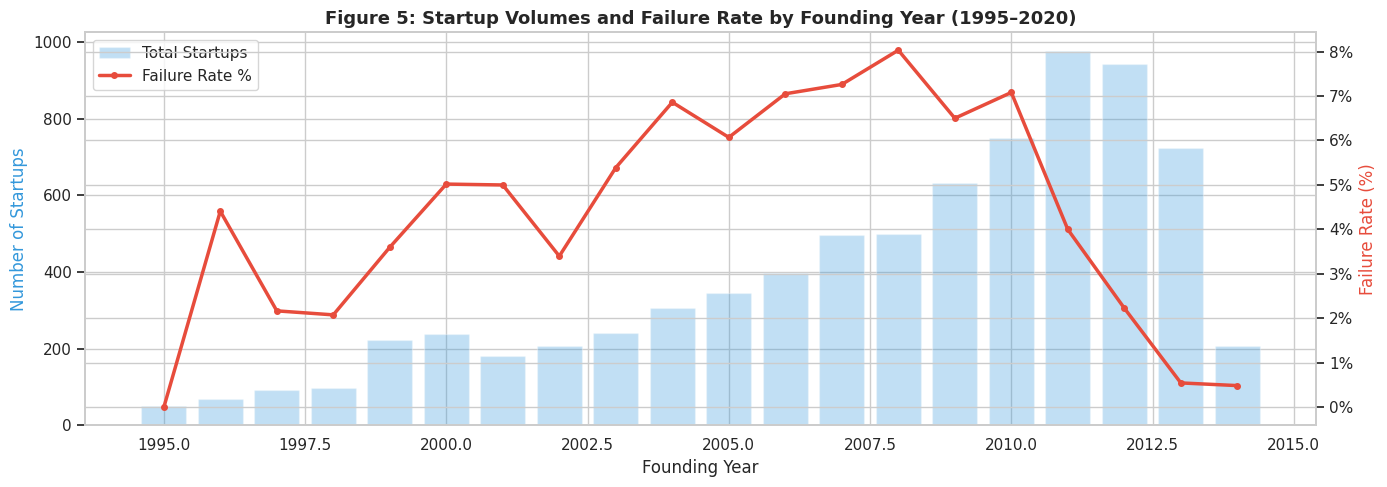

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import files

yearly = df[df['founded_year'].between(1995, 2020)].groupby('founded_year').agg(
    total=('is_closed', 'count'),
    closed=('is_closed', 'sum')
).reset_index()

yearly['failure_rate'] = (yearly['closed'] / yearly['total'] * 100).round(2)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(
    yearly['founded_year'],
    yearly['total'],
    alpha=0.3,
    color='#3498DB',
    label='Total Startups'
)

ax2.plot(
    yearly['founded_year'],
    yearly['failure_rate'],
    color='#E74C3C',
    linewidth=2.5,
    marker='o',
    markersize=4,
    label='Failure Rate %'
)

ax1.set_xlabel('Founding Year')
ax1.set_ylabel('Number of Startups', color='#3498DB')
ax2.set_ylabel('Failure Rate (%)', color='#E74C3C')

ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax1.set_title(
    'Figure 5: Startup Volumes and Failure Rate by Founding Year (1995–2020)',
    fontweight='bold',
    fontsize=13
)

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()

# SHOW plot
plt.show()

# ---- DOWNLOAD ----
filename = "eda_05_failure_trend.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

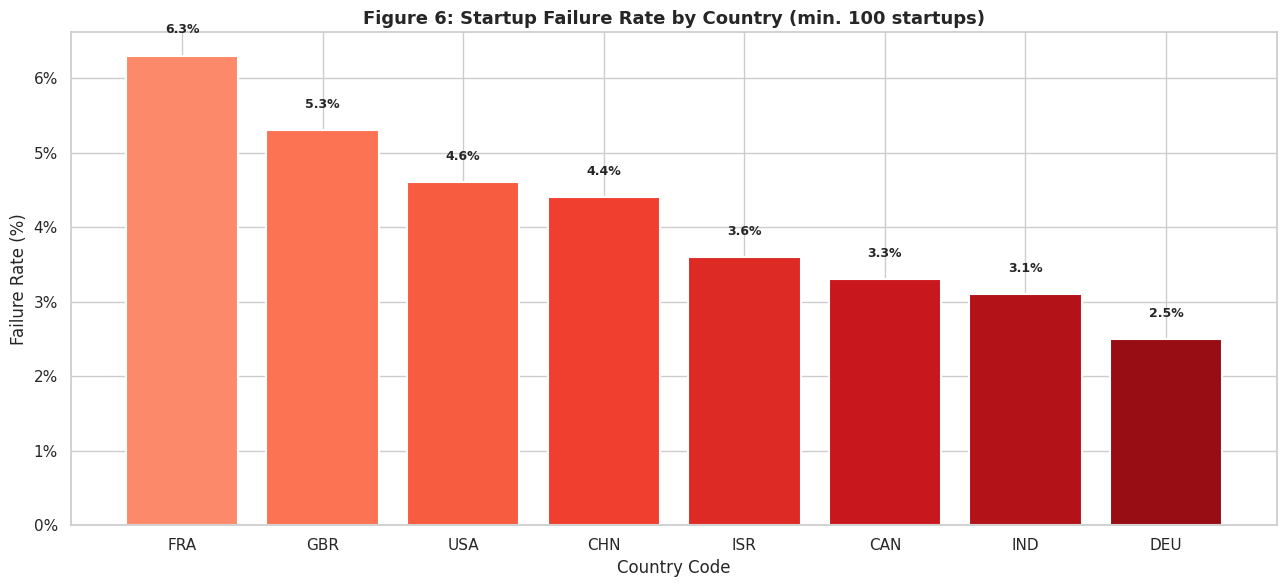

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import files

country_stats = df.groupby('country_code').agg(
    total=('is_closed', 'count'),
    closed=('is_closed', 'sum')
).reset_index()

country_stats = country_stats[country_stats['total'] >= 100]
country_stats['failure_rate'] = (country_stats['closed'] / country_stats['total'] * 100).round(1)

country_stats = country_stats.sort_values('failure_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    country_stats['country_code'],
    country_stats['failure_rate'],
    color=plt.cm.Reds(np.linspace(0.4, 0.9, len(country_stats))),
    edgecolor='white',
    linewidth=1.5
)

for bar, val in zip(bars, country_stats['failure_rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax.set_title(
    'Figure 6: Startup Failure Rate by Country (min. 100 startups)',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Country Code')
ax.set_ylabel('Failure Rate (%)')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

plt.tight_layout()

# SHOW
plt.show()

# ---- DOWNLOAD ----
filename = "eda_06_failure_by_country.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

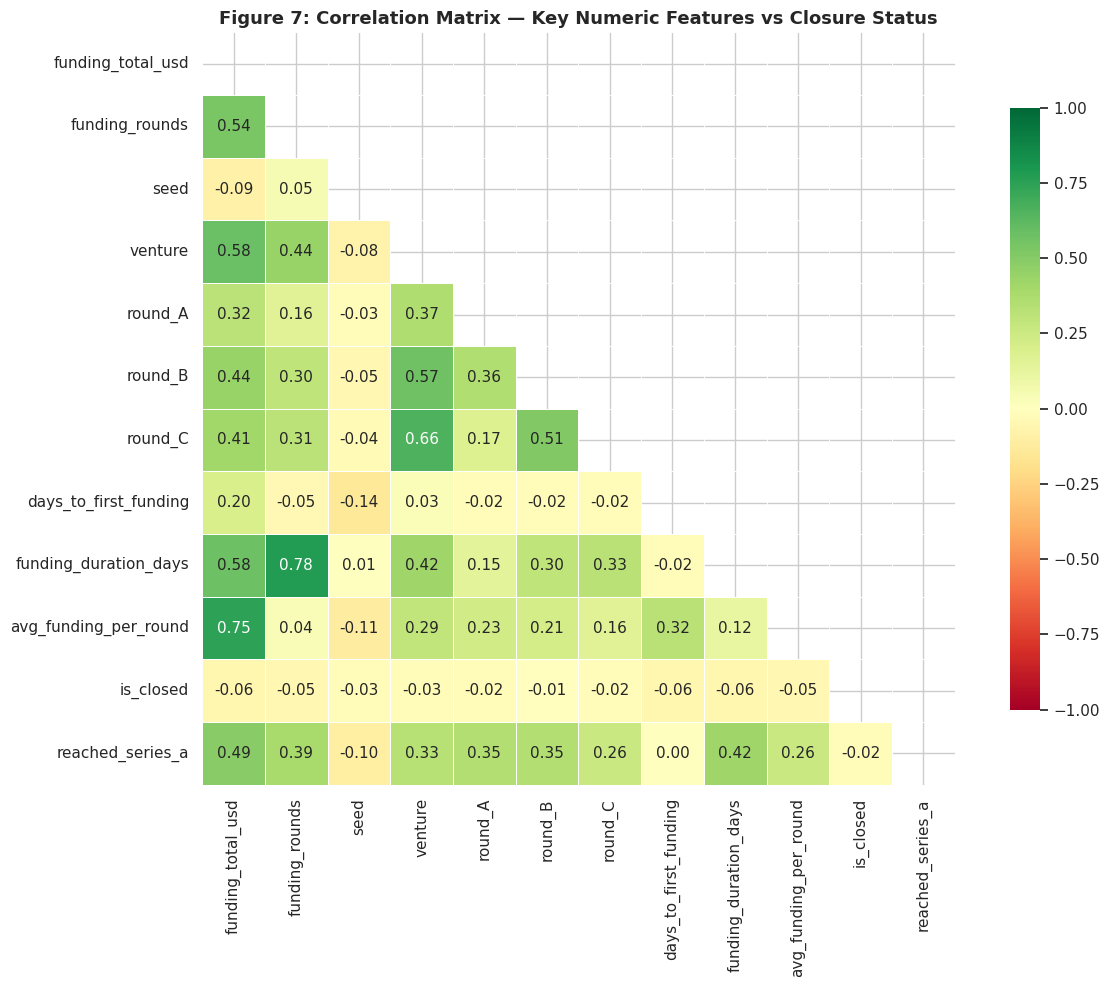

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

numeric_cols = [
    'funding_total_usd', 'funding_rounds', 'seed', 'venture',
    'round_A', 'round_B', 'round_C', 'days_to_first_funding',
    'funding_duration_days', 'avg_funding_per_round',
    'is_closed', 'reached_series_a'
]

corr_df = df[numeric_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title(
    'Figure 7: Correlation Matrix — Key Numeric Features vs Closure Status',
    fontweight='bold',
    fontsize=13
)

plt.tight_layout()

# SHOW
plt.show()

# ---- DOWNLOAD ----
filename = "eda_07_correlation_heatmap.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

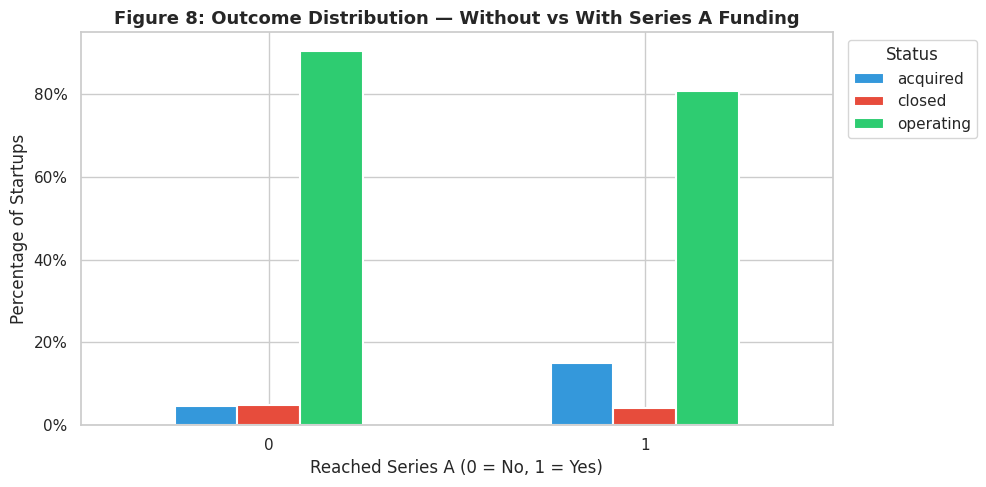

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from google.colab import files

series_a_survival = df.groupby(['reached_series_a', 'status']).size().unstack(fill_value=0)
series_a_pct = series_a_survival.div(series_a_survival.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))

series_a_pct.plot(
    kind='bar',
    ax=ax,
    color=[COLORS.get(c, '#95A5A6') for c in series_a_pct.columns],
    edgecolor='white',
    linewidth=1.5,
    rot=0
)

ax.set_title(
    'Figure 8: Outcome Distribution — Without vs With Series A Funding',
    fontweight='bold',
    fontsize=13
)

ax.set_xlabel('Reached Series A (0 = No, 1 = Yes)')
ax.set_ylabel('Percentage of Startups')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

ax.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()

# SHOW
plt.show()

# ---- DOWNLOAD ----
filename = "eda_08_series_a_survival.png"
fig.savefig(filename, dpi=150, bbox_inches='tight')
files.download(filename)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# =========================
# 1. SURVIVAL CURVE
# =========================
df['funding_stage'] = pd.cut(
    df['funding_rounds'],
    bins=[0, 1, 2, 3, 5, 10, 50],
    labels=['0-1', '2', '3', '4-5', '6-10', '10+']
)

survival = df.groupby('funding_stage')['is_closed'].agg(['count', 'sum'])
survival['survival_rate'] = (1 - survival['sum'] / survival['count']) * 100

fig1, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(survival.index.astype(str), survival['survival_rate'], marker='o')
ax1.set_title('Survival vs Funding Stage')
ax1.set_ylabel('Survival %')
plt.tight_layout()
plt.show()

fig1.savefig("survival.png", dpi=150, bbox_inches='tight')
files.download("survival.png")


# =========================
# 2. TIME TO FAILURE
# =========================
failed = df[df['is_closed'] == 1].copy()
failed = failed.dropna(subset=['founded_year'])
failed['time_to_failure'] = 2024 - failed['founded_year']

fig2, ax2 = plt.subplots(figsize=(6,4))
ax2.hist(failed['time_to_failure'], bins=20, color='red', edgecolor='black')
ax2.set_title('Time to Failure')
ax2.set_xlabel('Years')
plt.tight_layout()
plt.show()

fig2.savefig("time_to_failure.png", dpi=150, bbox_inches='tight')
files.download("time_to_failure.png")


# =========================
# 3. VC EFFICIENCY
# =========================
df_fund = df[df['funding_total_usd'] > 0].copy()

eff = df_fund.groupby('is_closed')['funding_total_usd'].mean().reset_index()
eff['status'] = eff['is_closed'].map({0: 'Survived', 1: 'Failed'})

fig3, ax3 = plt.subplots(figsize=(6,4))

sns.barplot(x='status', y='funding_total_usd', data=eff,
            palette=['green', 'red'], ax=ax3)

ax3.set_title('VC Investment Efficiency')
ax3.set_ylabel('Avg Funding')

plt.tight_layout()
plt.show()

fig3.savefig("vc_efficiency.png", dpi=150, bbox_inches='tight')
files.download("vc_efficiency.png")